In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/raw/master_parking_dataset (1).csv")

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (31025, 13)


In [5]:
df.head()

,date,time,day_of_week,day_of_week_num,is_weekend,parking_area_id,total_slots,occupied_slots,available,occupancy,distance,price,user_selected
0,2025-01-01,06:00,Wednesday,2,0,A01,100,10,90,10.0,0.79,30,1
1,2025-01-01,07:00,Wednesday,2,0,A01,100,18,82,18.0,0.73,30,1
2,2025-01-01,08:00,Wednesday,2,0,A01,100,19,81,19.0,0.88,30,1
3,2025-01-01,09:00,Wednesday,2,0,A01,100,24,76,24.0,0.76,30,1
4,2025-01-01,10:00,Wednesday,2,0,A01,100,22,78,22.0,0.77,30,1


In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (31025, 13)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31025 entries, 0 to 31024
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             31025 non-null  str    
 1   time             31025 non-null  str    
 2   day_of_week      31025 non-null  str    
 3   day_of_week_num  31025 non-null  int64  
 4   is_weekend       31025 non-null  int64  
 5   parking_area_id  31025 non-null  str    
 6   total_slots      31025 non-null  int64  
 7   occupied_slots   31025 non-null  int64  
 8   available        31025 non-null  int64  
 9   occupancy        31025 non-null  float64
 10  distance         31025 non-null  float64
 11  price            31025 non-null  int64  
 12  user_selected    31025 non-null  int64  
dtypes: float64(2), int64(7), str(4)
memory usage: 3.8 MB


In [8]:
df.describe()

,day_of_week_num,is_weekend,total_slots,occupied_slots,available,occupancy,distance,price,user_selected
count,31025.000000,31025.000000,31025.00000,31025.000000,31025.000000,31025.000000,31025.000000,31025.000000,31025.000000
mean,2.997260,0.284932,130.00000,37.035778,92.964222,26.889686,1.799847,27.609508,0.717937
std,1.997974,0.451389,41.95303,26.773784,30.417969,13.905598,0.822248,5.919849,0.450011
min,0.000000,0.000000,80.00000,2.000000,41.000000,1.670000,0.510000,15.000000,0.000000
25%,1.000000,0.000000,100.00000,18.000000,70.000000,16.250000,1.150000,25.000000,0.000000
50%,3.000000,0.000000,120.00000,30.000000,86.000000,25.000000,1.600000,28.000000,1.000000
75%,5.000000,1.000000,150.00000,49.000000,110.000000,35.830000,2.350000,30.000000,1.000000
max,6.000000,1.000000,200.00000,157.000000,196.000000,78.500000,3.370000,40.000000,1.000000


In [9]:
df.isnull().sum()

date               0
time               0
day_of_week        0
day_of_week_num    0
is_weekend         0
parking_area_id    0
total_slots        0
occupied_slots     0
available          0
occupancy          0
distance           0
price              0
user_selected      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
invalid_slots = df[
    df["occupied_slots"] + df["available"] != df["total_slots"]
]

print("Invalid slot records:", len(invalid_slots))

Invalid slot records: 0


In [12]:
calculated_occupancy = (
    df["occupied_slots"] / df["total_slots"]
) * 100

difference = (
    calculated_occupancy - df["occupancy"]
).abs()

print("Maximum difference:", difference.max())

Maximum difference: 0.0033333333333445125


In [13]:
print(df[["occupied_slots", "total_slots", "occupancy"]].head(10))

   occupied_slots  total_slots  occupancy
0              10          100       10.0
1              18          100       18.0
2              19          100       19.0
3              24          100       24.0
4              22          100       22.0
5              22          100       22.0
6              22          100       22.0
7              34          100       34.0
8              30          100       30.0
9              28          100       28.0


In [14]:
invalid_occupancy = df[
    (df["occupancy"] < 0) |
    (df["occupancy"] > 100)
]

print("Invalid occupancy records:", len(invalid_occupancy))

Invalid occupancy records: 0


In [15]:
invalid_slots = df[
    df["occupied_slots"] + df["available"] != df["total_slots"]
]

print("Invalid slot records:", len(invalid_slots))

Invalid slot records: 0


In [16]:
calculated_occupancy = (
    df["occupied_slots"] / df["total_slots"]
) * 100

difference = (
    calculated_occupancy - df["occupancy"]
).abs()

print("Maximum difference:", difference.max())

Maximum difference: 0.0033333333333445125


In [17]:
print(df[["occupied_slots", "total_slots", "occupancy"]].head(10))

   occupied_slots  total_slots  occupancy
0              10          100       10.0
1              18          100       18.0
2              19          100       19.0
3              24          100       24.0
4              22          100       22.0
5              22          100       22.0
6              22          100       22.0
7              34          100       34.0
8              30          100       30.0
9              28          100       28.0


In [18]:
invalid_occupancy = df[
    (df["occupancy"] < 0) |
    (df["occupancy"] > 100)
]

print("Invalid occupancy records:", len(invalid_occupancy))

Invalid occupancy records: 0


In [19]:
df["date"] = pd.to_datetime(df["date"])

In [20]:
df["date"].dtype

dtype('<M8[us]')

In [21]:
df["hour"] = pd.to_datetime(df["time"]).dt.hour

C:\Users\VAMSI KRISHNA JAMI\AppData\Local\Temp\ipykernel_28492\1705072889.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hour"] = pd.to_datetime(df["time"]).dt.hour


In [22]:
df[["time", "hour"]].head(10)

,time,hour
0,06:00,6
1,07:00,7
2,08:00,8
3,09:00,9
4,10:00,10
5,11:00,11
6,12:00,12
7,13:00,13
8,14:00,14
9,15:00,15


In [23]:
df["day"] = df["date"].dt.day

In [24]:
df[["date", "day"]].head()

,date,day
0,2025-01-01,1
1,2025-01-01,1
2,2025-01-01,1
3,2025-01-01,1
4,2025-01-01,1


In [25]:
df["month"] = df["date"].dt.month

In [26]:
df[["date", "month"]].head()

,date,month
0,2025-01-01,1
1,2025-01-01,1
2,2025-01-01,1
3,2025-01-01,1
4,2025-01-01,1


In [27]:
df[
    [
        "date",
        "time",
        "hour",
        "day",
        "month",
        "day_of_week",
        "day_of_week_num",
        "is_weekend"
    ]
].head(10)

,date,time,hour,day,month,day_of_week,day_of_week_num,is_weekend
0,2025-01-01,06:00,6,1,1,Wednesday,2,0
1,2025-01-01,07:00,7,1,1,Wednesday,2,0
2,2025-01-01,08:00,8,1,1,Wednesday,2,0
3,2025-01-01,09:00,9,1,1,Wednesday,2,0
4,2025-01-01,10:00,10,1,1,Wednesday,2,0
5,2025-01-01,11:00,11,1,1,Wednesday,2,0
6,2025-01-01,12:00,12,1,1,Wednesday,2,0
7,2025-01-01,13:00,13,1,1,Wednesday,2,0
8,2025-01-01,14:00,14,1,1,Wednesday,2,0
9,2025-01-01,15:00,15,1,1,Wednesday,2,0


In [28]:
df = df.sort_values(
    ["parking_area_id", "date", "time"]
).reset_index(drop=True)

In [29]:
df["previous_occupancy"] = (
    df.groupby("parking_area_id")["occupancy"].shift(1)
)

In [30]:
df[
    [
        "parking_area_id",
        "date",
        "time",
        "occupancy",
        "previous_occupancy"
    ]
].head(15)

,parking_area_id,date,time,occupancy,previous_occupancy
0,A01,2025-01-01,06:00,10.0,NaN
1,A01,2025-01-01,07:00,18.0,10.0
2,A01,2025-01-01,08:00,19.0,18.0
3,A01,2025-01-01,09:00,24.0,19.0
4,A01,2025-01-01,10:00,22.0,24.0
5,A01,2025-01-01,11:00,22.0,22.0
6,A01,2025-01-01,12:00,22.0,22.0
7,A01,2025-01-01,13:00,34.0,22.0
8,A01,2025-01-01,14:00,30.0,34.0
9,A01,2025-01-01,15:00,28.0,30.0


In [31]:
df["target_occupancy"] = (
    df.groupby("parking_area_id")["occupancy"].shift(-1)
)

In [32]:
df = df.dropna(
    subset=["previous_occupancy", "target_occupancy"]
).reset_index(drop=True)

In [33]:
print("Rows after removing NaN:", len(df))
print(
    df[
        ["previous_occupancy", "target_occupancy"]
    ].isnull().sum()
)

Rows after removing NaN: 31015
previous_occupancy    0
target_occupancy      0
dtype: int64


In [34]:
features = [
    "hour",
    "day_of_week_num",
    "is_weekend",
    "month",
    "previous_occupancy",
    "total_slots",
    "parking_area_id"
]

target = "target_occupancy"

In [35]:
model_df = df[features + [target]].copy()

In [36]:
print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (31015, 8)


,hour,day_of_week_num,is_weekend,month,previous_occupancy,total_slots,parking_area_id,target_occupancy
0,7,2,0,1,10.0,100,A01,19.0
1,8,2,0,1,18.0,100,A01,24.0
2,9,2,0,1,19.0,100,A01,22.0
3,10,2,0,1,24.0,100,A01,22.0
4,11,2,0,1,22.0,100,A01,22.0


In [37]:
model_df = pd.get_dummies(
    model_df,
    columns=["parking_area_id"],
    drop_first=True,
    dtype=int
)

In [38]:
print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (31015, 11)


,hour,day_of_week_num,is_weekend,month,previous_occupancy,total_slots,target_occupancy,parking_area_id_A02,parking_area_id_A03,parking_area_id_A04,parking_area_id_A05
0,7,2,0,1,10.0,100,19.0,0,0,0,0
1,8,2,0,1,18.0,100,24.0,0,0,0,0
2,9,2,0,1,19.0,100,22.0,0,0,0,0
3,10,2,0,1,24.0,100,22.0,0,0,0,0
4,11,2,0,1,22.0,100,22.0,0,0,0,0


In [39]:
X = model_df.drop(columns=["target_occupancy"])
y = model_df["target_occupancy"]

In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (31015, 10)
y shape: (31015,)


In [41]:
df = df.sort_values(
    ["date", "time", "parking_area_id"]
).reset_index(drop=True)

In [42]:
model_df = df[features + [target]].copy()

model_df = pd.get_dummies(
    model_df,
    columns=["parking_area_id"],
    drop_first=True,
    dtype=int
)

In [43]:
X = model_df.drop(columns=["target_occupancy"])
y = model_df["target_occupancy"]

In [44]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [45]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24812, 10)
X_test : (6203, 10)
y_train: (24812,)
y_test : (6203,)


In [46]:
print("Training period:")
print(df.iloc[:split_index][["date", "time"]].head(1))
print(df.iloc[:split_index][["date", "time"]].tail(1))

print("\nTesting period:")
print(df.iloc[split_index:][["date", "time"]].head(1))
print(df.iloc[split_index:][["date", "time"]].tail(1))

Training period:
        date   time
0 2025-01-01  07:00
            date   time
24811 2025-10-19  22:00

Testing period:
            date   time
24812 2025-10-19  22:00
            date   time
31014 2025-12-31  21:00


In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
linear_model = LinearRegression()

In [49]:
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-1.06, 0.02,-1.1 ,...,-0.51,-0.18, 0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['hour','day_of_week_num','is_weekend',...,'parking_area_id_A03', 'parking_area_id_A04','parking_area_id_A05']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,19.38
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


In [50]:
y_pred_linear = linear_model.predict(X_test)

In [51]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred_linear[:10]
})

comparison

,Actual,Predicted
0,2.50,1.042913
1,9.50,6.563532
2,1.67,2.441001
3,5.00,14.736004
4,12.00,25.881074
5,5.00,16.996063
6,11.50,25.216939
7,10.83,15.184706
8,15.00,16.766701
9,18.00,15.050840


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [53]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

In [54]:
print("Linear Regression")
print("------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
------------------
MAE : 7.488596230757467
RMSE: 9.552397319604962
R²  : 0.5007358099106001


In [55]:
from sklearn.ensemble import RandomForestRegressor

In [56]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [57]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [58]:
y_pred_rf = rf_model.predict(X_test)

In [59]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

In [60]:
print("Random Forest")

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 3.6108182270326536
RMSE: 4.53978710102721
R²  : 0.8872344002184895


In [61]:
from sklearn.ensemble import GradientBoostingRegressor

In [62]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [63]:
gb_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [64]:
y_pred_gb = gb_model.predict(X_test)

In [65]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

In [66]:
print("Gradient Boosting")

print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting
MAE : 3.433709972396766
RMSE: 4.3221080474561555
R²  : 0.8977891734970714


In [67]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,7.488596,9.552397,0.500736
1,Random Forest,3.610818,4.539787,0.887234
2,Gradient Boosting,3.433710,4.322108,0.897789


In [68]:
results.sort_values("MAE")

,Model,MAE,RMSE,R2
2,Gradient Boosting,3.433710,4.322108,0.897789
1,Random Forest,3.610818,4.539787,0.887234
0,Linear Regression,7.488596,9.552397,0.500736


In [69]:
best_model_name = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

print("Best model:", best_model_name)

Best model: Gradient Boosting


In [70]:
model_map = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

best_model = model_map[best_model_name]

print(type(best_model))

<class 'sklearn.ensemble._gb.GradientBoostingRegressor'>


In [71]:
best_predictions = best_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": best_predictions[:20]
})

comparison

,Actual,Predicted
0,2.50,5.133667
1,9.50,8.633183
2,1.67,6.787278
3,5.00,8.224987
4,12.00,13.838932
5,5.00,6.610485
6,11.50,15.719408
7,10.83,10.048441
8,15.00,12.430838
9,18.00,17.923403


In [72]:
best_mae = mean_absolute_error(
    y_test,
    best_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(y_test, best_predictions)
)

best_r2 = r2_score(
    y_test,
    best_predictions
)

print("FINAL MODEL")
print("-----------")
print("Model:", best_model_name)
print("MAE :", best_mae)
print("RMSE:", best_rmse)
print("R²  :", best_r2)

FINAL MODEL
-----------
Model: Gradient Boosting
MAE : 3.433709972396766
RMSE: 4.3221080474561555
R²  : 0.8977891734970714


In [73]:
import joblib

In [74]:
joblib.dump(
    best_model,
    "../models/occupancy_model.pkl"
)

['../models/occupancy_model.pkl']

In [75]:
print("Model:", best_model_name)
print("MAE:", best_mae)
print("RMSE:", best_rmse)
print("R²:", best_r2)

Model: Gradient Boosting
MAE: 3.433709972396766
RMSE: 4.3221080474561555
R²: 0.8977891734970714


In [76]:
from sklearn.metrics import mean_absolute_percentage_error

non_zero_mask = y_test != 0

mape = mean_absolute_percentage_error(
    y_test[non_zero_mask],
    y_pred_gb[non_zero_mask]
) * 100

print("MAPE:", round(mape, 3), "%")

MAPE: 22.134 %


In [77]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

previous_occupancy     0.482207
hour                   0.440135
total_slots            0.030355
month                  0.021468
is_weekend             0.009714
parking_area_id_A04    0.006568
day_of_week_num        0.006542
parking_area_id_A03    0.003011
parking_area_id_A02    0.000000
parking_area_id_A05    0.000000
dtype: float64


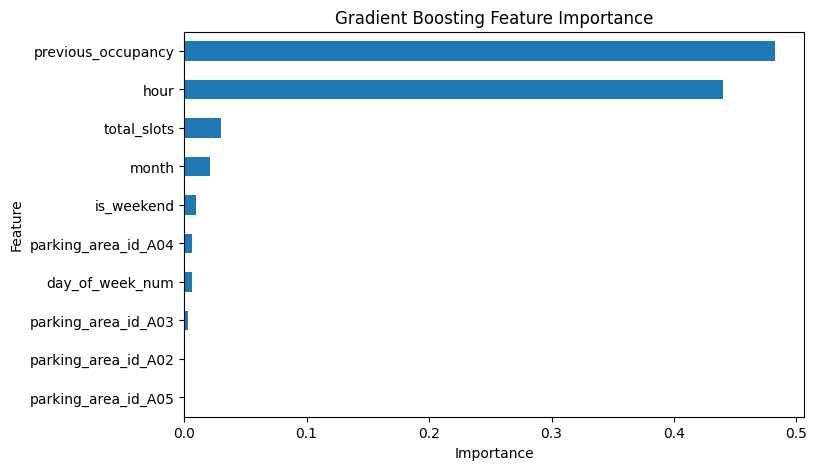

In [78]:
plt.figure(figsize=(8, 5))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [79]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

def occupancy_class(occupancy):
    if occupancy < 30:
        return "Low"
    elif occupancy < 70:
        return "Medium"
    else:
        return "High"

In [80]:
actual_classes = y_test.apply(occupancy_class)

predicted_classes = pd.Series(
    y_pred_gb,
    index=y_test.index
).apply(occupancy_class)

In [81]:
f1 = f1_score(
    actual_classes,
    predicted_classes,
    average="macro"
)

print("Macro F1 Score:", round(f1, 3))

Macro F1 Score: 0.605


In [82]:
print(
    classification_report(
        actual_classes,
        predicted_classes,
        digits=3
    )
)

              precision    recall  f1-score   support

        High      0.000     0.000     0.000         3
         Low      0.929     0.959     0.944      4245
      Medium      0.904     0.841     0.871      1955

    accuracy                          0.922      6203
   macro avg      0.611     0.600     0.605      6203
weighted avg      0.921     0.922     0.921      6203



C:\Users\VAMSI KRISHNA JAMI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VAMSI KRISHNA JAMI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VAMSI KRISHNA JAMI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [83]:
cm = confusion_matrix(
    actual_classes,
    predicted_classes,
    labels=["Low", "Medium", "High"]
)

print(cm)

[[4073  172    0]
 [ 311 1644    0]
 [   0    3    0]]


In [84]:
joblib.dump(
    best_model,
    "../models/occupancy_model.pkl"
)

['../models/occupancy_model.pkl']

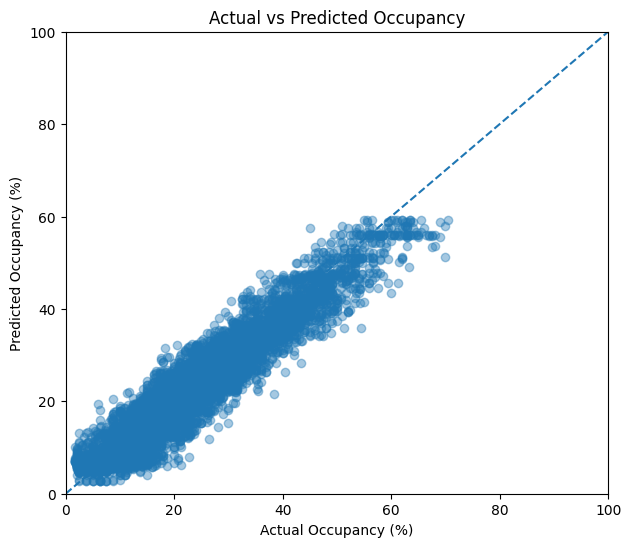

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlabel("Actual Occupancy (%)")
plt.ylabel("Predicted Occupancy (%)")
plt.title("Actual vs Predicted Occupancy")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.show()

In [86]:
residuals = y_test - y_pred_gb

print("Mean Residual:", round(residuals.mean(), 3))
print("Minimum Residual:", round(residuals.min(), 3))
print("Maximum Residual:", round(residuals.max(), 3))

Mean Residual: 0.904
Minimum Residual: -13.51
Maximum Residual: 18.713


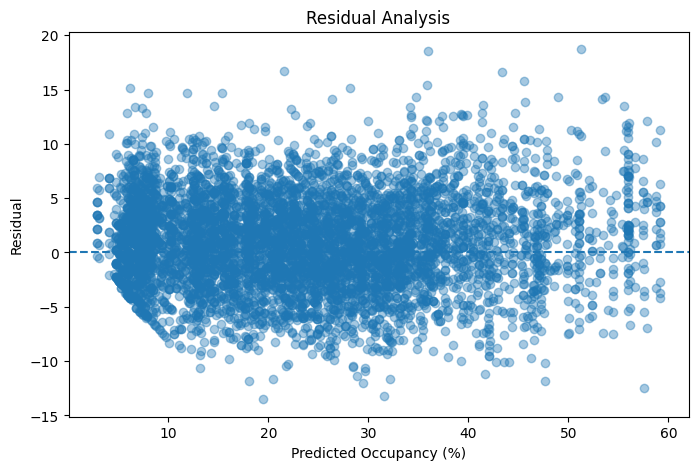

In [87]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_gb,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Occupancy (%)")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

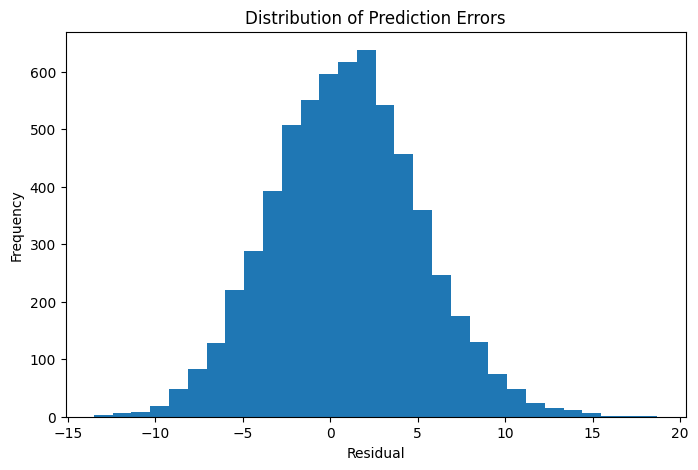

In [88]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.show()

In [89]:
print("Actual occupancy range:")
print("Minimum:", y_test.min())
print("Maximum:", y_test.max())

print("\nPredicted occupancy range:")
print("Minimum:", round(y_pred_gb.min(), 2))
print("Maximum:", round(y_pred_gb.max(), 2))

Actual occupancy range:
Minimum: 1.67
Maximum: 70.5

Predicted occupancy range:
Minimum: 2.83
Maximum: 59.2


In [90]:
analysis_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_gb
})

analysis_df["error"] = (
    analysis_df["actual"] -
    analysis_df["predicted"]
)

analysis_df["occupancy_range"] = pd.cut(
    analysis_df["actual"],
    bins=[0, 30, 50, 70, 100],
    labels=["Low (0-30)", "Medium (30-50)", "High (50-70)", "Very High (70-100)"],
    include_lowest=True
)

range_analysis = analysis_df.groupby(
    "occupancy_range",
    observed=False
).agg(
    samples=("actual", "count"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mae=("error", lambda x: x.abs().mean())
)

range_analysis

,samples,actual_mean,predicted_mean,mae
occupancy_range,,,,
Low (0-30),4354,17.065198,16.795573,3.206342
Medium (30-50),1572,38.191749,36.221024,3.710511
High (50-70),276,56.698116,51.901488,5.415456
Very High (70-100),1,70.500000,59.198008,11.301992


In [91]:
high_actual = analysis_df[
    analysis_df["actual"] >= 70
]

print(high_actual.head(20))
print("\nNumber of actual >= 70%:", len(high_actual))

      actual  predicted      error     occupancy_range
2521    70.0  51.286522  18.713478        High (50-70)
5496    70.5  59.198008  11.301992  Very High (70-100)
6176    70.0  57.874634  12.125366        High (50-70)

Number of actual >= 70%: 3


In [92]:
print("Complete Dataset Occupancy Distribution")
print("---------------------------------------")

print("Maximum occupancy:",
      df["occupancy"].max())

print("Records >= 70%:",
      (df["occupancy"] >= 70).sum())

print("Records >= 60%:",
      (df["occupancy"] >= 60).sum())

print("Records >= 50%:",
      (df["occupancy"] >= 50).sum())

print("Records >= 40%:",
      (df["occupancy"] >= 40).sum())

print("\nPercentage of dataset in each range:")

print(
    pd.cut(
        df["occupancy"],
        bins=[0, 30, 50, 70, 100],
        labels=[
            "Low (0-30)",
            "Medium (30-50)",
            "High (50-70)",
            "Very High (70-100)"
        ],
        include_lowest=True
    ).value_counts(
        normalize=True
    ).mul(100).round(2)
)

Complete Dataset Occupancy Distribution
---------------------------------------
Maximum occupancy: 78.5
Records >= 70%: 68
Records >= 60%: 577
Records >= 50%: 2174
Records >= 40%: 5645

Percentage of dataset in each range:
occupancy
Low (0-30)            63.34
Medium (30-50)        30.10
High (50-70)           6.37
Very High (70-100)     0.18
Name: proportion, dtype: float64


In [93]:
high_occupancy = df[
    df["occupancy"] >= 60
].copy()

print("Records with occupancy >= 60%:",
      len(high_occupancy))

high_occupancy[
    [
        "date",
        "time",
        "parking_area_id",
        "total_slots",
        "occupied_slots",
        "occupancy"
    ]
].head(20)

Records with occupancy >= 60%: 577


,date,time,parking_area_id,total_slots,occupied_slots,occupancy
138,2025-01-02,17:00,A04,200,124,62.00
143,2025-01-02,18:00,A04,200,131,65.50
223,2025-01-03,17:00,A04,200,122,61.00
228,2025-01-03,18:00,A04,200,125,62.50
478,2025-01-06,17:00,A04,200,129,64.50
483,2025-01-06,18:00,A04,200,136,68.00
561,2025-01-07,17:00,A02,150,102,68.00
563,2025-01-07,17:00,A04,200,139,69.50
566,2025-01-07,18:00,A02,150,100,66.67
568,2025-01-07,18:00,A04,200,125,62.50


In [94]:
high_by_hour = (
    high_occupancy
    .groupby("hour")
    .size()
    .sort_values(ascending=False)
)

print(high_by_hour)

hour
17    286
18    222
16     64
15      3
19      2
dtype: int64


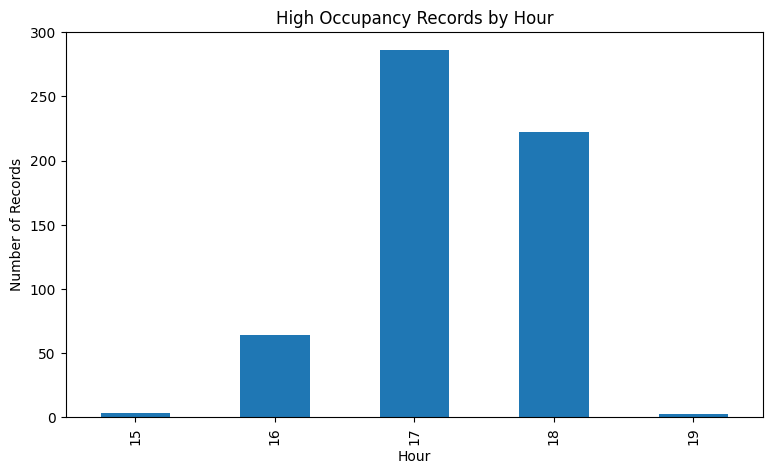

In [95]:
plt.figure(figsize=(9, 5))

high_by_hour.sort_index().plot(
    kind="bar"
)

plt.xlabel("Hour")
plt.ylabel("Number of Records")
plt.title("High Occupancy Records by Hour")

plt.show()

In [96]:
high_by_area = (
    high_occupancy
    .groupby("parking_area_id")
    .size()
    .sort_values(ascending=False)
)

print(high_by_area)

parking_area_id
A04    449
A02    122
A05      6
dtype: int64


In [97]:
high_by_area = (
    high_occupancy
    .groupby("parking_area_id")
    .size()
    .sort_values(ascending=False)
)

print(high_by_area)

parking_area_id
A04    449
A02    122
A05      6
dtype: int64


In [98]:
very_high = df[
    df["occupancy"] >= 70
]

print(
    very_high[
        [
            "date",
            "time",
            "day_of_week",
            "parking_area_id",
            "total_slots",
            "occupied_slots",
            "occupancy"
        ]
    ].to_string(index=False)
)

      date  time day_of_week parking_area_id  total_slots  occupied_slots  occupancy
2025-01-16 17:00    Thursday             A04          200             141       70.5
2025-01-22 17:00   Wednesday             A04          200             140       70.0
2025-01-30 17:00    Thursday             A04          200             140       70.0
2025-02-04 17:00     Tuesday             A04          200             149       74.5
2025-02-06 17:00    Thursday             A04          200             157       78.5
2025-02-10 18:00      Monday             A04          200             141       70.5
2025-02-13 17:00    Thursday             A04          200             140       70.0
2025-02-18 18:00     Tuesday             A04          200             140       70.0
2025-02-20 17:00    Thursday             A04          200             142       71.0
2025-02-24 17:00      Monday             A04          200             145       72.5
2025-02-26 17:00   Wednesday             A04          200        

In [99]:
print("Peak-period records")
print("-------------------")

peak_data = df[
    df["hour"].isin([16, 17, 18])
]

print("Total peak records:", len(peak_data))

print("\nAverage occupancy by hour:")
print(
    peak_data.groupby("hour")["occupancy"]
    .mean()
)

print("\nAverage occupancy by parking area:")
print(
    peak_data.groupby("parking_area_id")["occupancy"]
    .mean()
)

Peak-period records
-------------------
Total peak records: 5475

Average occupancy by hour:
hour
16    43.023447
17    47.053184
18    44.216340
Name: occupancy, dtype: float64

Average occupancy by parking area:
parking_area_id
A01    39.875799
A02    49.769982
A03    32.324201
A04    57.076256
A05    44.775379
Name: occupancy, dtype: float64


In [100]:
print("\nPeak occupancy by area and hour:")

print(
    peak_data
    .groupby(["parking_area_id", "hour"])["occupancy"]
    .mean()
    .round(2)
)


Peak occupancy by area and hour:
parking_area_id  hour
A01              16      38.24
                 17      41.92
                 18      39.47
A02              16      47.65
                 17      52.69
                 18      48.97
A03              16      31.12
                 17      33.73
                 18      32.12
A04              16      54.88
                 17      60.08
                 18      56.26
A05              16      43.23
                 17      46.84
                 18      44.26
Name: occupancy, dtype: float64


In [101]:
df["current_occupancy"] = df["occupancy"]

df["occupancy_change"] = (
    df["current_occupancy"] -
    df["previous_occupancy"]
)

print(
    df[
        [
            "parking_area_id",
            "hour",
            "previous_occupancy",
            "current_occupancy",
            "occupancy_change",
            "target_occupancy"
        ]
    ].head(10)
)

  parking_area_id  hour  previous_occupancy  current_occupancy  \
0             A01     7               10.00              18.00   
1             A02     7               14.00              18.67   
2             A03     7                2.50              15.00   
3             A04     7               17.50              18.50   
4             A05     7                7.50              17.50   
5             A01     8               18.00              19.00   
6             A02     8               18.67              26.67   
7             A03     8               15.00              15.00   
8             A04     8               18.50              26.00   
9             A05     8               17.50              20.00   

   occupancy_change  target_occupancy  
0              8.00             19.00  
1              4.67             26.67  
2             12.50             15.00  
3              1.00             26.00  
4             10.00             20.00  
5              1.00             2

In [102]:
features_v2 = [
    "hour",
    "day_of_week_num",
    "is_weekend",
    "month",
    "previous_occupancy",
    "current_occupancy",
    "occupancy_change",
    "total_slots",
    "parking_area_id"
]

target = "target_occupancy"

model_df_v2 = df[
    features_v2 + [target]
].copy()

model_df_v2 = pd.get_dummies(
    model_df_v2,
    columns=["parking_area_id"],
    drop_first=True,
    dtype=int
)

X_v2 = model_df_v2.drop(
    columns=["target_occupancy"]
)

y_v2 = model_df_v2["target_occupancy"]

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

X_v2 shape: (31015, 12)
y_v2 shape: (31015,)


In [103]:
split_index_v2 = int(len(X_v2) * 0.8)

X_train_v2 = X_v2.iloc[:split_index_v2]
X_test_v2 = X_v2.iloc[split_index_v2:]

y_train_v2 = y_v2.iloc[:split_index_v2]
y_test_v2 = y_v2.iloc[split_index_v2:]

print("X_train_v2:", X_train_v2.shape)
print("X_test_v2:", X_test_v2.shape)

X_train_v2: (24812, 12)
X_test_v2: (6203, 12)


In [104]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model_v2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model_v2.fit(
    X_train_v2,
    y_train_v2
)

y_pred_gb_v2 = gb_model_v2.predict(
    X_test_v2
)

In [105]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_v2 = mean_absolute_error(
    y_test_v2,
    y_pred_gb_v2
)

rmse_v2 = np.sqrt(
    mean_squared_error(
        y_test_v2,
        y_pred_gb_v2
    )
)

r2_v2 = r2_score(
    y_test_v2,
    y_pred_gb_v2
)

print("Gradient Boosting V2")
print("--------------------")
print("MAE :", round(mae_v2, 3))
print("RMSE:", round(rmse_v2, 3))
print("R²  :", round(r2_v2, 3))

Gradient Boosting V2
--------------------
MAE : 3.364
RMSE: 4.243
R²  : 0.901


In [106]:
print("V2 Prediction Range")
print("-------------------")

print("Actual minimum:", y_test_v2.min())
print("Actual maximum:", y_test_v2.max())

print("Predicted minimum:", round(y_pred_gb_v2.min(), 2))
print("Predicted maximum:", round(y_pred_gb_v2.max(), 2))


V2 Prediction Range
-------------------
Actual minimum: 1.67
Actual maximum: 70.5
Predicted minimum: 3.86
Predicted maximum: 63.12


In [107]:
analysis_v2 = pd.DataFrame({
    "actual": y_test_v2.values,
    "predicted": y_pred_gb_v2
})

analysis_v2["error"] = (
    analysis_v2["actual"] -
    analysis_v2["predicted"]
)

analysis_v2["occupancy_range"] = pd.cut(
    analysis_v2["actual"],
    bins=[0, 30, 50, 70, 100],
    labels=[
        "Low (0-30)",
        "Medium (30-50)",
        "High (50-70)",
        "Very High (70-100)"
    ],
    include_lowest=True
)

range_analysis_v2 = analysis_v2.groupby(
    "occupancy_range",
    observed=False
).agg(
    samples=("actual", "count"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    mae=("error", lambda x: x.abs().mean())
)

range_analysis_v2

,samples,actual_mean,predicted_mean,mae
occupancy_range,,,,
Low (0-30),4354,17.065198,17.154267,3.139683
Medium (30-50),1572,38.191749,36.952557,3.730009
High (50-70),276,56.698116,53.102875,4.789367
Very High (70-100),1,70.500000,62.194901,8.305099


In [108]:
from sklearn.metrics import mean_absolute_percentage_error

non_zero_mask_v2 = y_test_v2 != 0

mape_v2 = mean_absolute_percentage_error(
    y_test_v2[non_zero_mask_v2],
    y_pred_gb_v2[non_zero_mask_v2]
) * 100

print("V2 MAPE:", round(mape_v2, 3), "%")

V2 MAPE: 21.947 %


In [109]:
actual_classes_v2 = y_test_v2.apply(occupancy_class)

predicted_classes_v2 = pd.Series(
    y_pred_gb_v2,
    index=y_test_v2.index
).apply(occupancy_class)

f1_v2 = f1_score(
    actual_classes_v2,
    predicted_classes_v2,
    average="macro"
)

print("V2 Macro F1 Score:", round(f1_v2, 3))

V2 Macro F1 Score: 0.604


In [110]:
print(
    classification_report(
        actual_classes_v2,
        predicted_classes_v2,
        digits=3
    )
)

              precision    recall  f1-score   support

        High      0.000     0.000     0.000         3
         Low      0.930     0.955     0.942      4245
      Medium      0.894     0.845     0.868      1955

    accuracy                          0.919      6203
   macro avg      0.608     0.600     0.604      6203
weighted avg      0.918     0.919     0.919      6203



C:\Users\VAMSI KRISHNA JAMI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VAMSI KRISHNA JAMI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\VAMSI KRISHNA JAMI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [111]:
cm_v2 = confusion_matrix(
    actual_classes_v2,
    predicted_classes_v2,
    labels=["Low", "Medium", "High"]
)

print("V2 Confusion Matrix:")
print(cm_v2)

V2 Confusion Matrix:
[[4052  193    0]
 [ 304 1651    0]
 [   0    3    0]]


In [112]:
feature_importance_v2 = pd.Series(
    gb_model_v2.feature_importances_,
    index=X_train_v2.columns
).sort_values(ascending=False)

print(feature_importance_v2)

current_occupancy      0.779193
hour                   0.179383
previous_occupancy     0.012980
month                  0.009357
total_slots            0.008557
day_of_week_num        0.004307
occupancy_change       0.002556
is_weekend             0.002462
parking_area_id_A04    0.000645
parking_area_id_A03    0.000561
parking_area_id_A02    0.000000
parking_area_id_A05    0.000000
dtype: float64


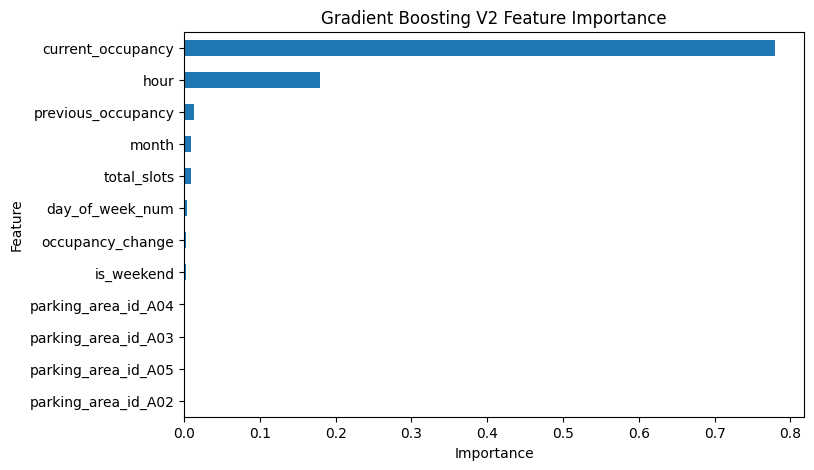

In [113]:
plt.figure(figsize=(8, 5))

feature_importance_v2.sort_values().plot(
    kind="barh"
)

plt.title("Gradient Boosting V2 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [114]:
import joblib

model_path_v2 = "../models/occupancy_model.pkl"

joblib.dump(
    gb_model_v2,
    model_path_v2
)

print("V2 model saved successfully!")
print("Model:", model_path_v2)

V2 model saved successfully!
Model: ../models/occupancy_model.pkl
